# Model

One fixed, untuned LightGBM on all feature blocks, trained before 2015-07-01 and validated on the three months after. Calibration is checked alongside AUC because the pricing layer multiplies these probabilities by a cost.

In [1]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")
import json
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from src.data import INTERIM
from src.models import time_split

CUTOFF = "2015-07-01"
CATS = ["deviceID", "paymentMethod"]
DROP = ["orderID", "orderDate", "customerID", "any_return"]

def gbm():
    return lgb.LGBMClassifier(n_estimators=800, learning_rate=0.03, num_leaves=31, min_child_samples=50,
                              subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=2.0,
                              n_jobs=-1, verbose=-1)

## Assemble

**Assemble the four blocks.** Left joins on `orderID` preserve every order even where a block has no matching row. Order matters only for readability — the joins are keyed, not positional.

In [2]:
df = pd.read_parquet(INTERIM / "orders.parquet")
for block in ["basket", "customer", "article"]:
    df = df.merge(pd.read_parquet(INTERIM / f"{block}.parquet"), on="orderID", how="left")
df.shape

(738698, 40)

**Build the matrix and split.** 36 features after dropping identifiers, the date and the target. Categoricals are cast to `category` so LightGBM can split on category *subsets* natively rather than needing one-hot expansion. The split gives 624,732 training orders before the cutoff and 113,966 after.

In [3]:
FEATS = [c for c in df.columns if c not in DROP]
X = df[FEATS].copy()
for c in CATS:
    X[c] = X[c].astype("category")
y = df.any_return
tr, va = time_split(df, "orderDate", CUTOFF)
len(FEATS), int(tr.sum()), int(va.sum())

(36, 624732, 113966)

## Fit

**Fit and compare against the baseline.** AUC 0.7959 → 0.8526, a +0.0567 lift that is entirely attributable to the engineered features.

In [4]:
m = gbm().fit(X[tr], y[tr])
pred = m.predict_proba(X[va])[:, 1]

base = json.loads((INTERIM / "baseline.json").read_text())
res = {"auc": roc_auc_score(y[va], pred), "logloss": log_loss(y[va], pred),
       "brier": brier_score_loss(y[va], pred)}
print(f"baseline  AUC {base['auc']:.4f}   logloss {base['logloss']:.4f}")
print(f"full      AUC {res['auc']:.4f}   logloss {res['logloss']:.4f}   brier {res['brier']:.4f}")
print(f"lift      AUC +{res['auc'] - base['auc']:.4f}")

baseline  AUC 0.7959   logloss 0.5218
full      AUC 0.8526   logloss 0.4527   brier 0.1507
lift      AUC +0.0567


## Calibration

**Calibration, which matters more than AUC here.** `qcut` makes ten equal-sized bins by predicted probability and compares mean predicted against actual within each. ECE is the size-weighted mean absolute gap: 0.0047. AUC only measures ranking; the pricing layer multiplies these probabilities by dollars, so being right about the *level* is what licenses the economics.

In [5]:
cal = pd.DataFrame({"pred": pred, "actual": y[va].values})
cal["bin"] = pd.qcut(cal.pred, 10, labels=False, duplicates="drop")
rel = cal.groupby("bin").agg(n=("pred", "size"), mean_pred=("pred", "mean"), actual=("actual", "mean"))
rel["gap"] = rel.mean_pred - rel.actual
ece = float((rel.n / rel.n.sum() * rel.gap.abs()).sum())
res["ece"] = ece
print(f"expected calibration error {ece:.4f}")
rel.round(4)

expected calibration error 0.0047


,n,mean_pred,actual,gap
bin,,,,
0,11397,0.1517,0.1556,-0.0039
1,11397,0.2774,0.2800,-0.0025
2,11396,0.3778,0.3800,-0.0023
3,11397,0.4820,0.4771,0.0049
4,11396,0.5955,0.5959,-0.0004
5,11397,0.7182,0.7037,0.0146
6,11396,0.8324,0.8206,0.0119
7,11397,0.9206,0.9199,0.0007
8,11396,0.9721,0.9774,-0.0053


## Reliability

**Reliability diagram.** Points on the diagonal mean predicted equals actual. Deviations above the line are over-confidence, below is under-confidence.

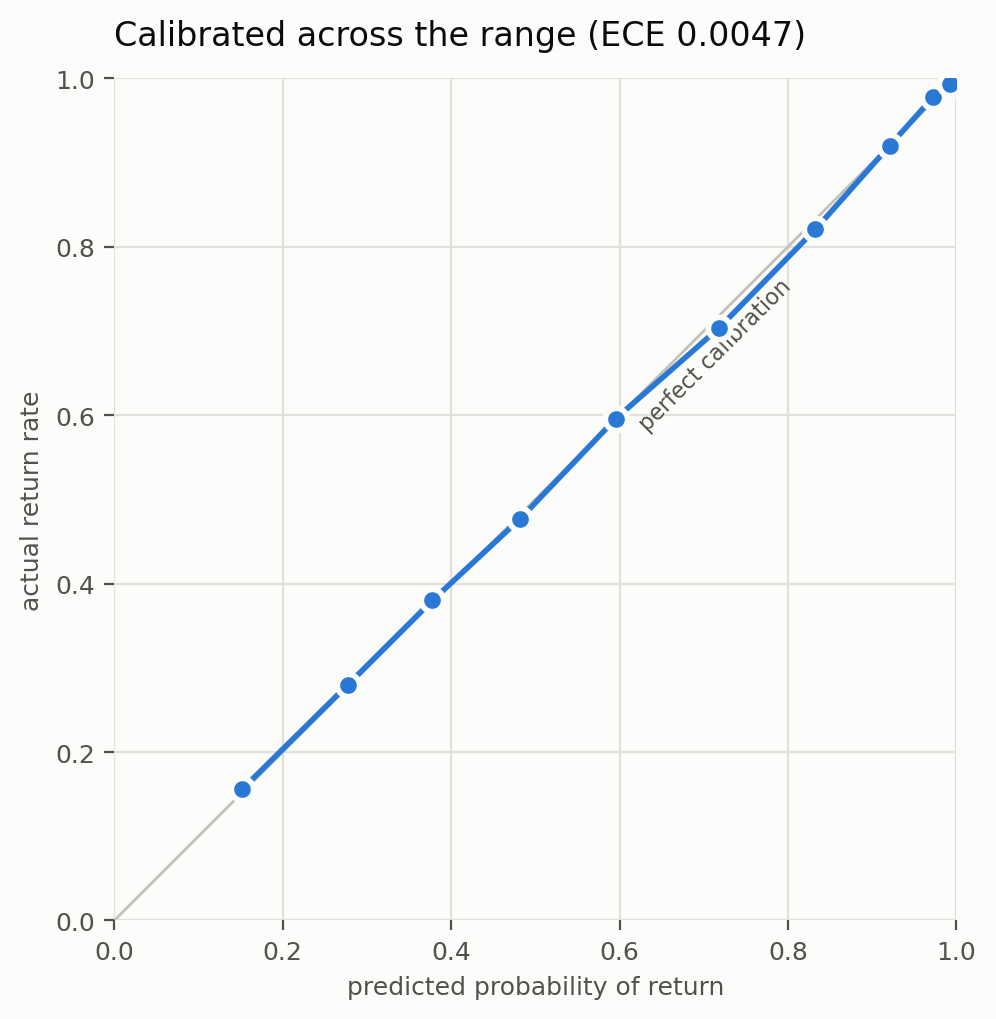

In [6]:
import matplotlib.pyplot as plt
from src.data import ROOT

SURFACE, GRID, INK, MUTED, BASE, SLOT1 = "#fcfcfb", "#e1e0d9", "#0b0b0b", "#52514e", "#c3c2b7", "#2a78d6"
FIGURES = ROOT / "figures"; FIGURES.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(5.2, 5.2), dpi=200)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
ax.plot([0, 1], [0, 1], color=BASE, linewidth=1, zorder=2)
ax.annotate("perfect calibration", (0.62, 0.62), xytext=(4, -12), textcoords="offset points",
            color=MUTED, fontsize=8, rotation=45, rotation_mode="anchor")
ax.plot(rel.mean_pred, rel.actual, color=SLOT1, linewidth=2, marker="o", markersize=8,
        markeredgecolor=SURFACE, markeredgewidth=2, zorder=3)
ax.grid(True, color=GRID, linewidth=0.8, linestyle="-", zorder=1)
ax.set_axisbelow(True)
for s in ax.spines.values(): s.set_visible(False)
ax.set_xlabel("predicted probability of return", color=MUTED, fontsize=9)
ax.set_ylabel("actual return rate", color=MUTED, fontsize=9)
ax.set_title(f"Calibrated across the range (ECE {ece:.4f})", color=INK, fontsize=12, pad=12, loc="left")
ax.tick_params(colors=MUTED, labelsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
fig.tight_layout()
fig.savefig(FIGURES / "reliability_diagram.png", facecolor=SURFACE, bbox_inches="tight")
plt.show()

**Precision, recall and lift at top k.** Read this one sceptically: with a 63.5% base rate the maximum possible lift is 1/0.635 = 1.58, and the model sits essentially at that ceiling, so precision looks spectacular and means little. The genuinely useful end of this model is the *low-risk tail* — orders that will not come back — which is exactly what the coverage product needs to find.

In [7]:
order = np.argsort(-pred)
actual_va = y[va].values
total_returns = actual_va.sum()

rows = []
for k in [0.01, 0.05, 0.10, 0.20, 0.50]:
    n = int(len(pred) * k)
    hit = actual_va[order[:n]]
    rows.append({"top_k": k, "n": n, "precision": hit.mean(),
                 "recall": hit.sum() / total_returns,
                 "lift_vs_base": hit.mean() / actual_va.mean()})
prec = pd.DataFrame(rows)
res["precision_at_10"] = float(prec.loc[prec.top_k == 0.10, "precision"].iloc[0])
prec.round(4)

,top_k,n,precision,recall,lift_vs_base
0,0.01,1139,0.9956,0.0158,1.5794
1,0.05,5698,0.9967,0.0790,1.5810
2,0.10,11396,0.9938,0.1576,1.5764
3,0.20,22793,0.9856,0.3127,1.5635
4,0.50,56983,0.8831,0.7004,1.4008


## Importance

**LightGBM gain importance.** Useful but biased toward high-cardinality features; notebook 11 cross-checks it with permutation importance, which measures what the validation *score* actually depends on.

In [8]:
imp = pd.Series(m.booster_.feature_importance("gain"), index=FEATS).sort_values(ascending=False)
imp.head(20).round(0)

rrp_total                 1235028.0
order_value                492358.0
cust_past_return_rate      478964.0
max_sizes_per_article      408678.0
paymentMethod              159249.0
n_items                    102836.0
article_rate_max            88040.0
multi_size                  84459.0
n_articles                  71454.0
article_rate_mean           57960.0
cust_mean_prev_value        50739.0
cust_prior_orders           38654.0
n_lines                     36338.0
max_colors_per_article      26872.0
artsize_rate_max            26546.0
artsize_rate_mean           18303.0
article_prior_n_mean        18127.0
group_rate_mean             17853.0
mean_discount               16572.0
cust_prev_order_value       16529.0
dtype: float64

## Save

**Persist validation predictions** for the pricing notebooks, so 08, 09, 12 and 15 all price against the same scored orders.

In [9]:
out = df.loc[va, ["orderID", "orderDate", "order_value", "n_items", "n_lines", "any_return"]].copy()
out["pred"] = pred
out.to_parquet(INTERIM / "predictions.parquet", index=False)
imp.to_csv(INTERIM / "importance.csv")
(INTERIM / "model.json").write_text(json.dumps(res, indent=2))
out.shape, res

((113966, 7),
 {'auc': 0.8526000625721792,
  'logloss': 0.45266894253040507,
  'brier': 0.15067666920514422,
  'ece': 0.004746563837678346,
  'precision_at_10': 0.9937697437697438})